In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

In [14]:
df = pd.read_csv("./assignment-datasets/us_retail_sales.csv")

In [15]:
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,146925,147223,146805,148032,149010,149800,150761.0,151067.0,152588.0,153521.0,153583.0,155614.0
1,1993,157555,156266,154752,158979,160605,160127,162816.0,162506.0,163258.0,164685.0,166594.0,168161.0
2,1994,167518,169649,172766,173106,172329,174241,174781.0,177295.0,178787.0,180561.0,180703.0,181524.0
3,1995,182413,179488,181013,181686,183536,186081,185431.0,186806.0,187366.0,186565.0,189055.0,190774.0
4,1996,189135,192266,194029,194744,196205,196136,196187.0,196218.0,198859.0,200509.0,200174.0,201284.0


In [16]:
'''
Reshape the data so that the month and year are combined into one column.
Utilize the melt() function to transpose the MONTH features in combination with the YEAR column.
Remove any extra columns that are not needed for the dataframe.
'''
df2=pd.melt(df, id_vars='YEAR', var_name='Month', value_name='#Sales')

In [17]:
df2.head()

,YEAR,Month,#Sales
0,1992,JAN,146925.0
1,1993,JAN,157555.0
2,1994,JAN,167518.0
3,1995,JAN,182413.0
4,1996,JAN,189135.0


In [18]:
## Create date string column for conversion
df2['date_str'] = df2.apply(lambda row: str(row.YEAR) + "-" + str(row.Month) + "-01", axis=1)

## Convert date_string to date_time
df2['datetime'] = df2['date_str'].apply(lambda x: pd.to_datetime(x, format='%Y-%b-%d'))

## Drop unnecessary columns
df2 = df2[['datetime', '#Sales']].sort_values(by='datetime').reset_index(drop=True)

# Drop NA
df2.dropna(inplace=True)

In [19]:
df2.head()

,datetime,#Sales
0,1992-01-01,146925.0
1,1992-02-01,147223.0
2,1992-03-01,146805.0
3,1992-04-01,148032.0
4,1992-05-01,149010.0


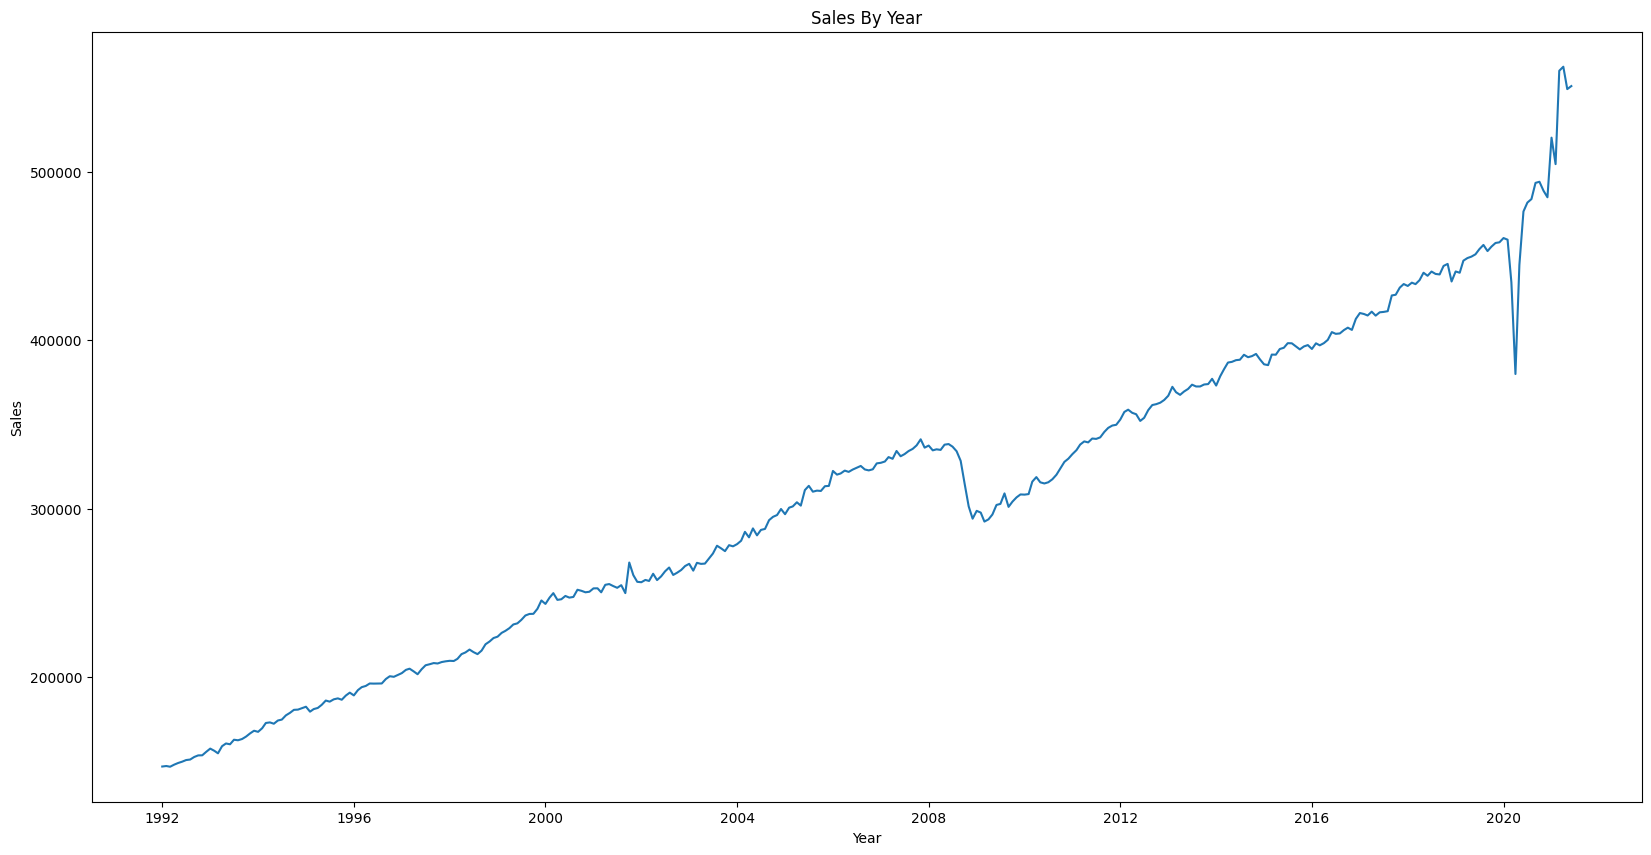

In [20]:
## Show number of sales year by year
plt.rcParams["figure.figsize"] = (20,10)
plt.plot(df2['datetime'], df2['#Sales'])
plt.title('Sales By Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

### Observations

US Retail sales have been steadily increasing since 1992. As you can see in the chart, small decreases in retail sales were seen during the 2008-2009 and at the begining of 2020.

In [29]:
## Split this data into a training and test set. Use the last year of data (July 2020 – June 2021) of data as your test set and the rest as your training set.
train_df = df2[df2['datetime'] < '2020-07-01']

X_train = train_df['datetime']
Y_train = train_df['#Sales']

In [30]:
## Split out test data
test_df = df2[df2['datetime'] >= '2020-07-01']

x_test = test_df['datetime']
y_test = test_df['#Sales']

RMSE: 73875.521


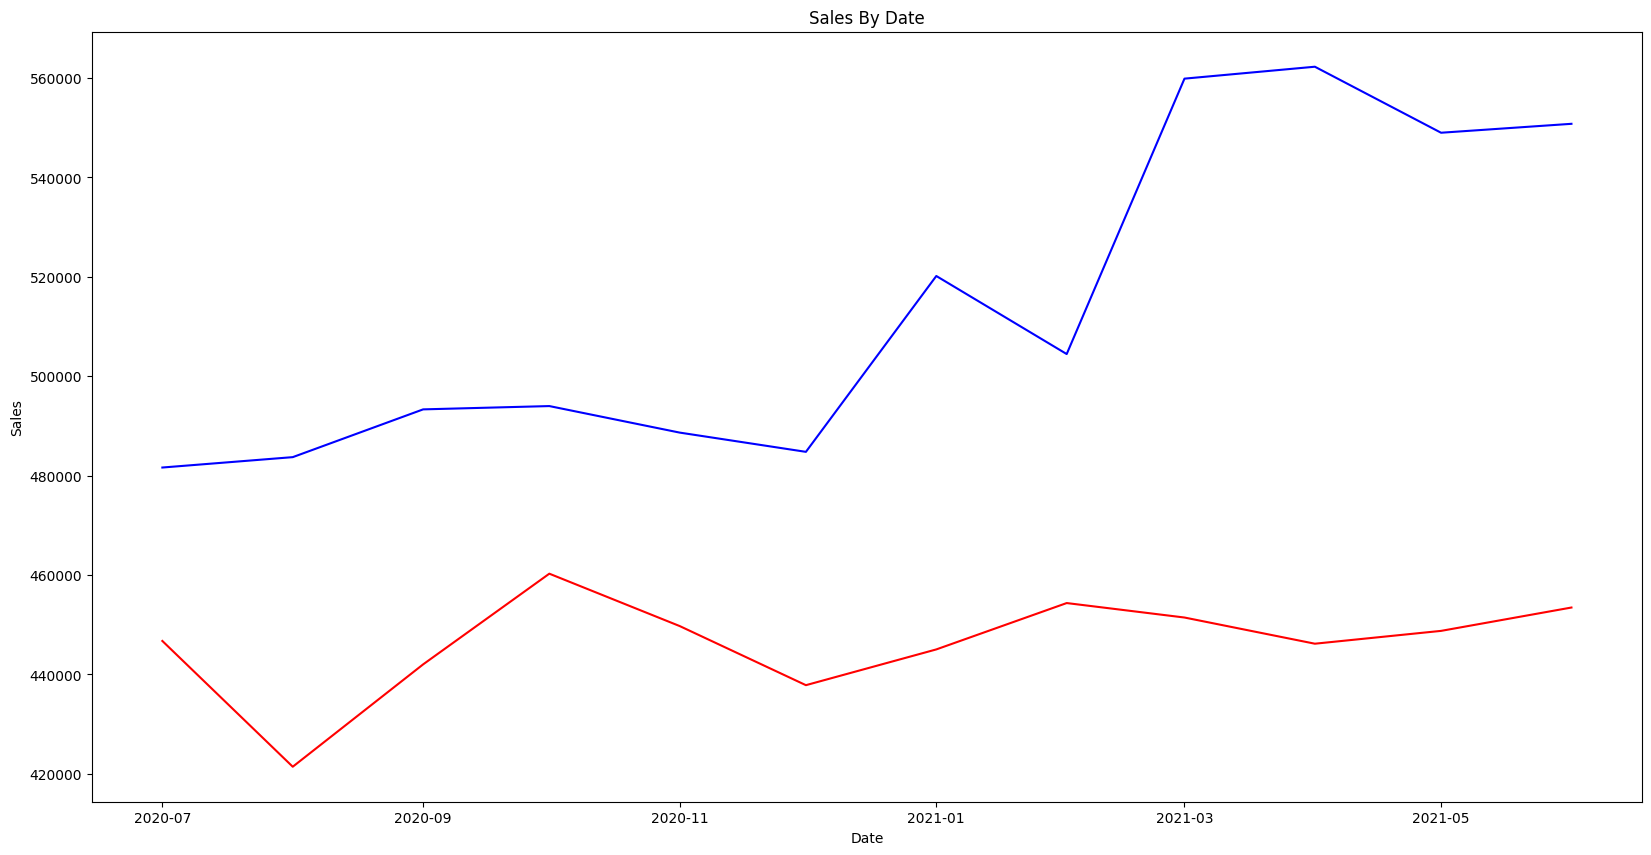

In [32]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
from math import sqrt

#Use the model to predict the monthly retail sales on the last year of data.

model = AutoReg(Y_train, lags=5)
model_fit = model.fit()

predictions = model_fit.predict(start=len(Y_train), end=(len(Y_train) + len(y_test)) - 1, dynamic=False)

# test_df['estimate'] = predictions
test_df.loc[:,'estimate'] = predictions

rmse = sqrt(mean_squared_error(y_test, predictions))
print('RMSE: %.3f' % rmse)

## Show sales over time
plt.plot(test_df['datetime'], test_df['#Sales'], label='Actual', c='blue')
plt.plot(test_df['datetime'], test_df['estimate'], label='Estimate', c='red')
plt.title('Sales By Date')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

RMSE value is too high so lets try other models.

RMSE: 52206.764


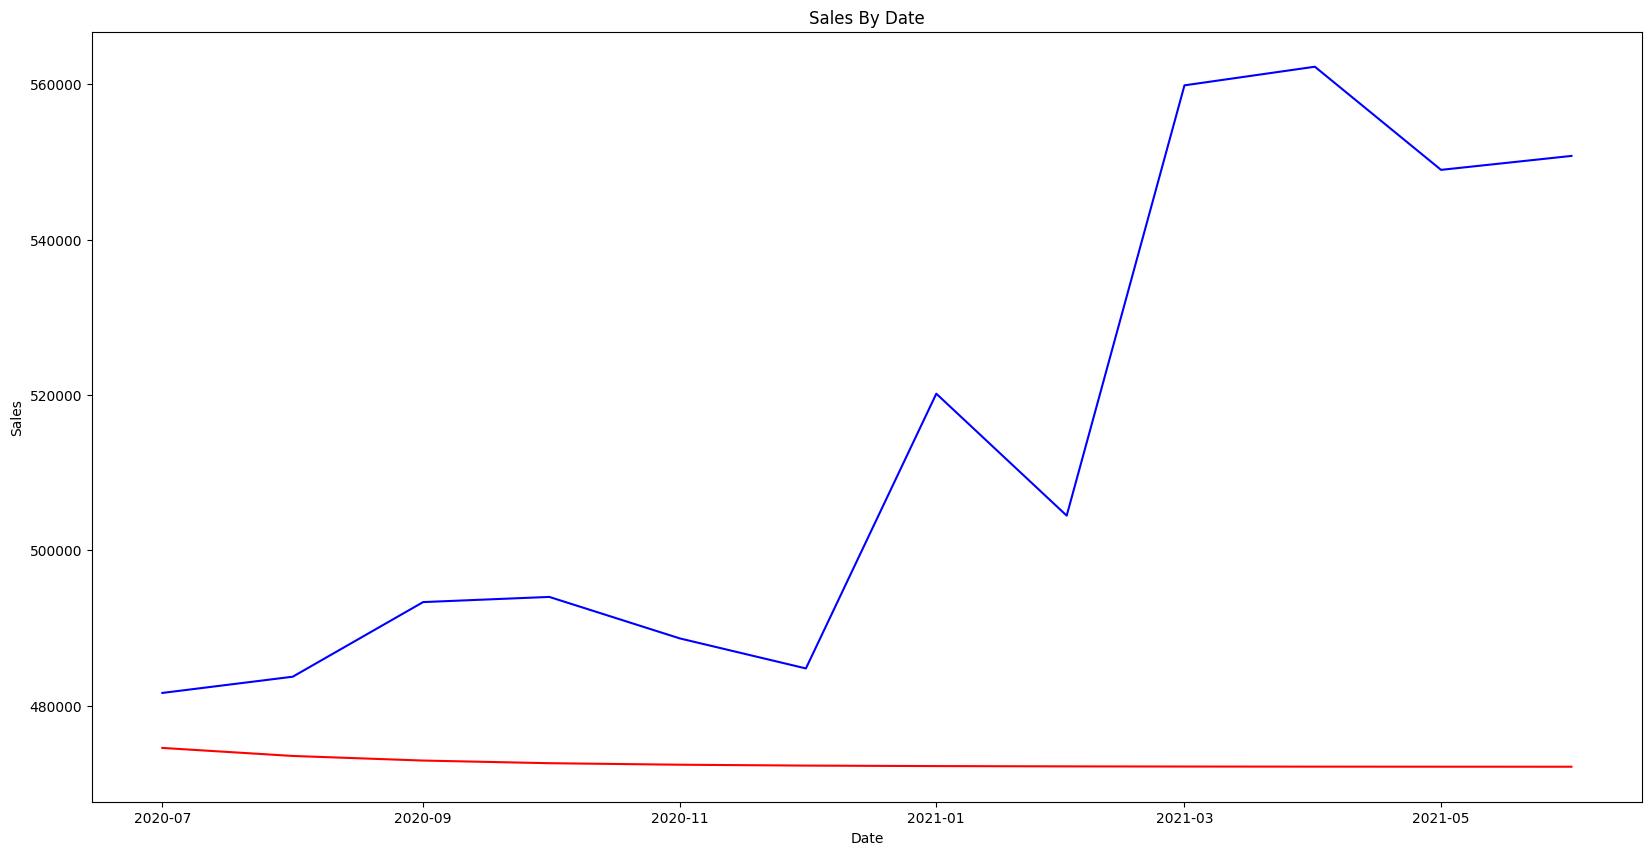

In [33]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

model = ARIMA(Y_train, order=(1, 1, 1))
model_fit = model.fit()

predictions = model_fit.predict(start=len(Y_train), end=(len(Y_train) + len(y_test)) - 1, dynamic=False)

test_df.loc[:,'estimate'] = predictions

rmse = sqrt(mean_squared_error(y_test, predictions))
print('RMSE: %.3f' % rmse)

## Show sales over time
plt.plot(test_df['datetime'], test_df['#Sales'], label='Actual', c='blue')
plt.plot(test_df['datetime'], test_df['estimate'], label='Estimate', c='red')
plt.title('Sales By Date')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

RMSE: 52206.764


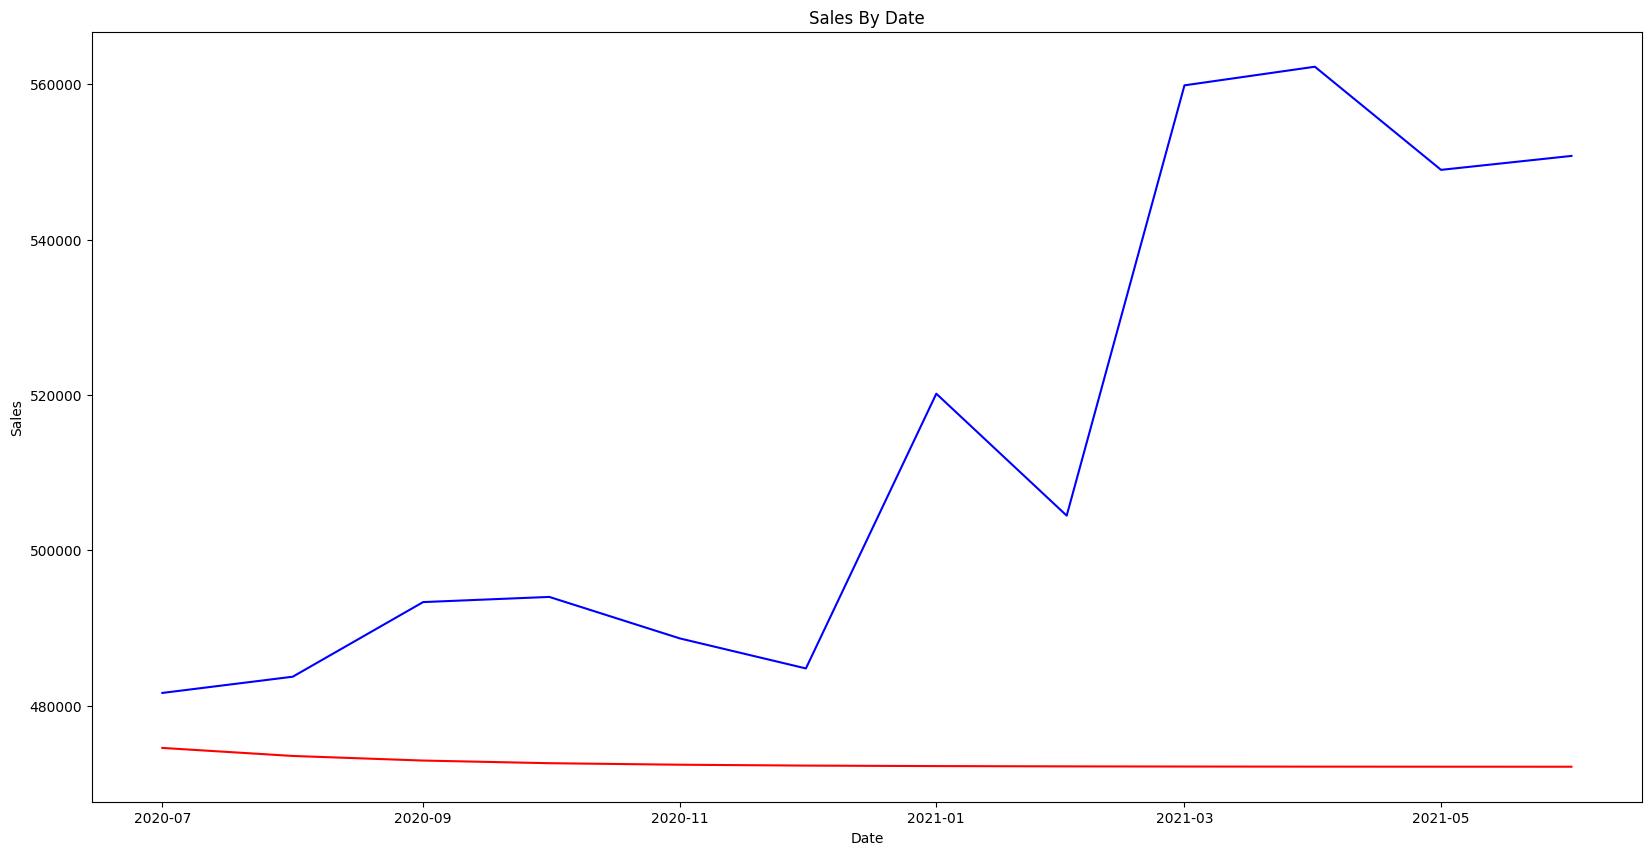

In [34]:
# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt

model = ARIMA(Y_train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
model_fit = model.fit()

predictions = model_fit.predict(start=len(Y_train), end=(len(Y_train) + len(y_test)) - 1, dynamic=False)

test_df.loc[:,'estimate'] = predictions

rmse = sqrt(mean_squared_error(y_test, predictions))
print('RMSE: %.3f' % rmse)

## Show sales over time
plt.plot(test_df['datetime'], test_df['#Sales'], label='Actual', c='blue')
plt.plot(test_df['datetime'], test_df['estimate'], label='Estimate', c='red')
plt.title('Sales By Date')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()